In [1]:
from vnstock import *

**Vui lòng chuyển đổi sang Vnstock3** thế hệ mới (3.1.0) với câu lệnh: `pip install vnstock3 --upgrade`.
**Từ 1/1/2025, vnstock3 sẽ được cài đặt khi sử dụng cú pháp** `pip install vnstock` **thay cho Vnstock Legacy** hiện tại.
Xem chi tiết [chuyển đổi sang vnstock3](https://vnstocks.com/docs/tai-lieu/migration-chuyen-doi-sang-vnstock3).
Phiên bản **Vnstock Legacy (0.2.9.2.3)** bạn đang sử dụng **sẽ không được nâng cấp thêm.**
Từ 7/10/2024 Vnstock giới thiệu nhóm Facebook Cộng đồng Vnstock, tham gia thảo luận tại đây: https://www.facebook.com/groups/vnstock.official

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error
import os
import random

In [3]:
import tensorflow as tf
import tensorflow.keras.backend as K
from tensorflow.keras.layers import LSTM, Flatten, Dense, Masking, GRU
from tensorflow.keras.models import Sequential
from scikeras.wrappers import KerasRegressor
from sklearn.preprocessing import MinMaxScaler
from keras.callbacks import EarlyStopping
from sklearn.metrics import r2_score

In [4]:
import warnings
warnings.filterwarnings('ignore')

In [5]:
seed_value = 18  # Bạn có thể thay đổi seed theo ý muốn

os.environ['PYTHONHASHSEED'] = str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)


In [6]:
start_date='2015-01-01'
end_date='2024-03-31'
#df=stock_historical_data('FPT',start_date,end_date)
df=pd.read_csv('VNINDEX.csv')

In [7]:
df.columns=['time','close','open','high','low','volume','%']

In [8]:
df

,time,close,open,high,low,volume,%
0,28/06/2024,"1,245.32","1,259.09","1,262.61","1,240.15",840.43K,-1.09%
1,27/06/2024,"1,259.09","1,261.24","1,262.49","1,255.12",596.99K,-0.17%
2,26/06/2024,"1,261.24","1,256.56","1,262.67","1,247.55",878.37K,0.37%
3,25/06/2024,"1,256.56","1,254.12","1,260.07","1,250.25",835.30K,0.19%
4,24/06/2024,"1,254.12","1,282.02","1,284.84","1,252.66",1.25M,-2.18%
...,...,...,...,...,...,...,...
2363,09/01/2015,569.73,555.53,570.52,555.53,107.48K,2.94%
2364,08/01/2015,553.47,553.49,556.80,552.15,77.87K,0.26%
2365,07/01/2015,552.05,548.44,555.83,548.44,111.71K,0.43%
2366,06/01/2015,549.66,539.08,550.11,538.82,112.32K,0.96%


In [9]:
df.set_index('time',inplace=True)
#Nếu dùng cho cổ phiếu thì dùng:
##df.index=pd.to_datetime(df.index,format='%Y-%m-%d')
#Nếu dùng cho VNINDEX thì dùng
df.index=pd.to_datetime(df.index,format='%d/%m/%Y')
df=df.sort_values('time')

In [10]:
pos_df=df.reset_index()

In [11]:
index_pos=pos_df[pos_df['time']=='2022-12-30'].index[0]

In [12]:
df['close'] = df['close'].str.replace(',', '').astype(float)

In [13]:
scaler = MinMaxScaler(feature_range=(0, 1))

In [14]:
df['scaled_close']=scaler.fit_transform(df[['close']])

In [15]:
df

,close,open,high,low,volume,%,scaled_close
time,,,,,,,
2015-01-05,544.45,545.43,549.22,543.78,95.95K,-0.22%,0.022420
2015-01-06,549.66,539.08,550.11,538.82,112.32K,0.96%,0.027595
2015-01-07,552.05,548.44,555.83,548.44,111.71K,0.43%,0.029970
2015-01-08,553.47,553.49,556.80,552.15,77.87K,0.26%,0.031380
2015-01-09,569.73,555.53,570.52,555.53,107.48K,2.94%,0.047532
...,...,...,...,...,...,...,...
2024-06-24,1254.12,"1,282.02","1,284.84","1,252.66",1.25M,-2.18%,0.727374
2024-06-25,1256.56,"1,254.12","1,260.07","1,250.25",835.30K,0.19%,0.729798
2024-06-26,1261.24,"1,256.56","1,262.67","1,247.55",878.37K,0.37%,0.734447


In [16]:
# Lấy giá đóng cửa
#Cho giá cổ phiếu
#train_data = df[['close']].iloc[:'2022-12-31'].values
#test_data = df[['close']].iloc['2023-01-01':'2023-12-31'].values
#Cho VNINDEX
train_data = df[['scaled_close']].iloc[:index_pos].values
test_data = df[['scaled_close']].iloc[index_pos:].values


# Tạo tập dữ liệu cho mô hình LSTM
def create_multistep_dataset(data, time_step, predict_step):
    X, y = [], []
    for i in range(time_step, len(data) - predict_step + 1):
        X.append(data[i-time_step:i, 0])  # Lấy 50 ngày trước đó làm đầu vào
        y.append(data[i:i+predict_step, 0])  # Lấy 5 ngày tiếp theo làm đầu ra
    return np.array(X), np.array(y)

time_step = 20
predict_step = 1
X_train, y_train = create_multistep_dataset(train_data, time_step, predict_step)
X_test, y_test = create_multistep_dataset(test_data, time_step, predict_step)

# Reshape dữ liệu cho LSTM [samples, time_steps, features]
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)


In [17]:
X_train

array([[[0.02242001],
        [0.02759539],
        [0.0299695 ],
        ...,
        [0.06146877],
        [0.06099196],
        [0.05382988]],

       [[0.02759539],
        [0.0299695 ],
        [0.03138007],
        ...,
        [0.06099196],
        [0.05382988],
        [0.04816776]],

       [[0.0299695 ],
        [0.03138007],
        [0.04753201],
        ...,
        [0.05382988],
        [0.04816776],
        [0.03535349]],

       ...,

       [[0.50688891],
        [0.52304086],
        [0.51098153],
        ...,
        [0.49740238],
        [0.49514746],
        [0.46025092]],

       [[0.52304086],
        [0.51098153],
        [0.55442092],
        ...,
        [0.49514746],
        [0.46025092],
        [0.47948226]],

       [[0.51098153],
        [0.55442092],
        [0.56799015],
        ...,
        [0.46025092],
        [0.47948226],
        [0.49049856]]])

In [18]:
model_mix = Sequential([
    LSTM(units=256, return_sequences=True, input_shape=(time_step, 1)),  # LSTM layer đầu tiên
    GRU(units=256, return_sequences=False),
    Dense(units=256),
    Dense(units=predict_step)
])
# Compile mô hình
model_mix.compile(optimizer='adam', loss='mean_squared_error')

# Huấn luyện mô hình
model_mix.fit(X_train, y_train, batch_size=32, epochs=100,shuffle=True)


Epoch 1/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 12s 112ms/step - loss: 0.0259
Epoch 2/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 7s 115ms/step - loss: 5.2911e-04
Epoch 3/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 7s 112ms/step - loss: 4.0730e-04
Epoch 4/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 7s 112ms/step - loss: 3.6178e-04
Epoch 5/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 7s 112ms/step - loss: 3.2081e-04
Epoch 6/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 7s 112ms/step - loss: 3.0325e-04
Epoch 7/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 7s 109ms/step - loss: 2.9251e-04
Epoch 8/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 7s 112ms/step - loss: 3.0104e-04
Epoch 9/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 7s 112ms/step - loss: 2.9158e-04
Epoch 10/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 7s 111ms/step - loss: 2.8085e-04
Epoch 11/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 7s 111ms/step - loss: 2.7097e-04
Epoch 12/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 7s 112ms/step - loss: 2.6139e-04
Epoch 13/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 8s 135ms/step - loss: 2.5207e-04
Epoch 14/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 9s 114ms/step - loss: 2

In [19]:
model_GRU = Sequential([
    GRU(units=64, return_sequences=True, input_shape=(time_step, 1)),  # LSTM layer đầu tiên
    GRU(units=32, return_sequences=False),
    Dense(units=32),
    Dense(units=predict_step)
])
# Compile mô hình
model_GRU.compile(optimizer='adam', loss='mean_squared_error')

# Huấn luyện mô hình
model_GRU.fit(X_train, y_train, batch_size=32, epochs=100,shuffle=False)


Epoch 1/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 0.0022
Epoch 2/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0034
Epoch 3/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0057
Epoch 4/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0099
Epoch 5/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0156
Epoch 6/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0208
Epoch 7/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0264
Epoch 8/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0297
Epoch 9/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0151
Epoch 10/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0038
Epoch 11/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 1.2851e-04
Epoch 12/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 1.6319e-04
Epoch 13/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 2.0456e-04
Epoch 14/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 2.6297e-04
Epoch 15/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1

In [20]:
model_LSTM = Sequential([
    LSTM(units=64, return_sequences=True, input_shape=(time_step, 1)),  # LSTM layer đầu tiên
    LSTM(units=32, return_sequences=False),
    Dense(units=32),
    Dense(units=predict_step)
])
# Compile mô hình
model_LSTM.compile(optimizer='adam', loss='mean_squared_error')

# Huấn luyện mô hình
model_LSTM.fit(X_train, y_train, batch_size=32, epochs=100,shuffle=False)


Epoch 1/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.0028
Epoch 2/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0102
Epoch 3/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0175
Epoch 4/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0282
Epoch 5/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0408
Epoch 6/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0167
Epoch 7/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0023
Epoch 8/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 7.2902e-04
Epoch 9/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 7.3743e-04
Epoch 10/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 8.2011e-04
Epoch 11/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 9.4229e-04
Epoch 12/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0011  
Epoch 13/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0012
Epoch 14/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0014
Epoch 15/100
62/62 ━━━━━━━━━━━━━━━━━━━━

In [21]:
# Dự đoán giá
yhat_train_mix = model_mix.predict(X_train)
yhat_test_mix = model_mix.predict(X_test)

# Đảo ngược chuẩn hóa
yhat_train_mix = scaler.inverse_transform(yhat_train_mix)
yhat_test_mix = scaler.inverse_transform(yhat_test_mix)

62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step


In [22]:
# Dự đoán giá
yhat_train_GRU = model_GRU.predict(X_train)
yhat_test_GRU = model_GRU.predict(X_test)

# Đảo ngược chuẩn hóa
yhat_train_GRU = scaler.inverse_transform(yhat_train_GRU)
yhat_test_GRU = scaler.inverse_transform(yhat_test_GRU)

62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


In [23]:
# Dự đoán giá
yhat_train_LSTM = model_LSTM.predict(X_train)
yhat_test_LSTM = model_LSTM.predict(X_test)

# Đảo ngược chuẩn hóa
yhat_train_LSTM = scaler.inverse_transform(yhat_train_LSTM)
yhat_test_LSTM = scaler.inverse_transform(yhat_test_LSTM)

62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


In [24]:
y_train_plot=scaler.inverse_transform(y_train)
y_test_plot=scaler.inverse_transform(y_test)

In [25]:
MSE_train=[mean_squared_error(y_train_plot,yhat_train_mix),
     mean_squared_error(y_train_plot,yhat_train_GRU),
     mean_squared_error(y_train_plot,yhat_train_LSTM)]
RMSE_train=[root_mean_squared_error(y_train_plot,yhat_train_mix),
      root_mean_squared_error(y_train_plot,yhat_train_GRU),
      root_mean_squared_error(y_train_plot,yhat_train_LSTM)]
MAE_train=[mean_absolute_error(y_train_plot,yhat_train_mix),
     mean_absolute_error(y_train_plot,yhat_train_GRU),
     mean_absolute_error(y_train_plot,yhat_train_LSTM)]
R2_train=[r2_score(y_train_plot,yhat_train_mix),
     r2_score(y_train_plot,yhat_train_GRU),
     r2_score(y_train_plot,yhat_train_LSTM)]
error_train_table=pd.DataFrame({'R2':R2_train,
                                'MSE':MSE_train,
                                'RMSE':RMSE_train,
                               'MAE':MAE_train})
error_train_table.index=['LSTM_GRU','GRU','LSTM']

In [26]:
MSE_test=[mean_squared_error(y_test_plot,yhat_test_mix),
     mean_squared_error(y_test_plot,yhat_test_GRU),
     mean_squared_error(y_test_plot,yhat_test_LSTM)]
RMSE_test=[root_mean_squared_error(y_test_plot,yhat_test_mix),
      root_mean_squared_error(y_test_plot,yhat_test_GRU),
      root_mean_squared_error(y_test_plot,yhat_test_LSTM)]
MAE_test=[mean_absolute_error(y_test_plot,yhat_test_mix),
     mean_absolute_error(y_test_plot,yhat_test_GRU),
     mean_absolute_error(y_test_plot,yhat_test_LSTM)]
R2_test=[r2_score(y_test_plot,yhat_test_mix),
     r2_score(y_test_plot,yhat_test_GRU),
     r2_score(y_test_plot,yhat_test_LSTM)]
error_test_table=pd.DataFrame({'R2':R2_test,
                                'MSE':MSE_test,
                                'RMSE':RMSE_test,
                               'MAE':MAE_test})
error_test_table.index=['LSTM_GRU','GRU','LSTM']

In [27]:
error_train_table.round(6)

,R2,MSE,RMSE,MAE
LSTM_GRU,0.997942,144.088887,12.003703,7.737173
GRU,0.969047,2167.605554,46.557551,40.499658
LSTM,0.974248,1803.383109,42.466258,38.182045


In [28]:
error_test_table.round(6)

,R2,MSE,RMSE,MAE
LSTM_GRU,0.977614,143.890784,11.995448,8.437969
GRU,0.952526,305.155872,17.468711,14.045821
LSTM,0.868384,846.002984,29.086130,25.868722


In [29]:
y_train_draw=y_train_plot.reshape(y_train_plot.shape[0],)
yhat_train_mix_draw=yhat_train_mix.reshape(yhat_train_mix.shape[0],)
yhat_train_LSTM_draw=yhat_train_LSTM.reshape(yhat_train_mix.shape[0],)
yhat_train_GRU_draw=yhat_train_GRU.reshape(yhat_train_mix.shape[0],)

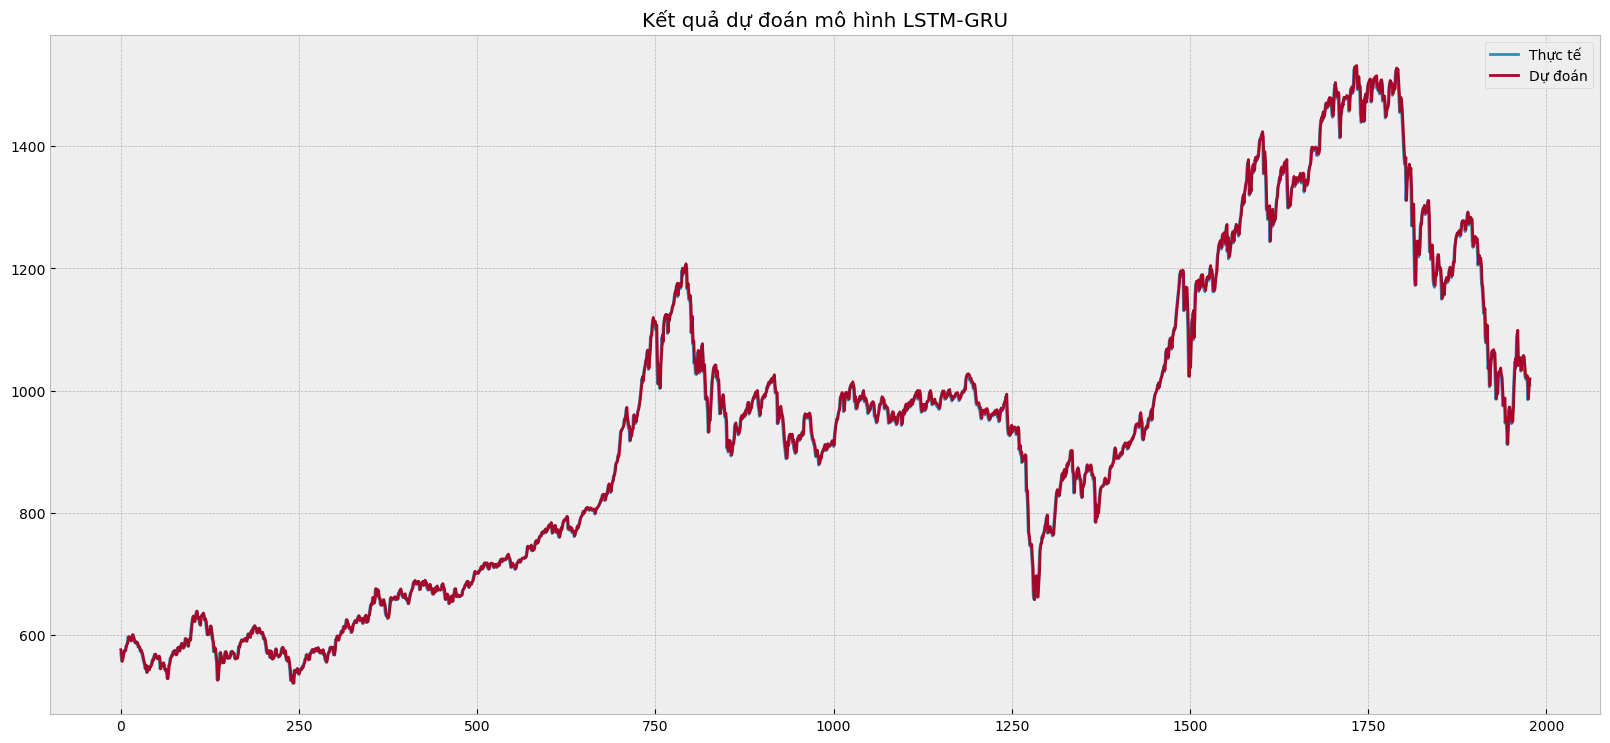

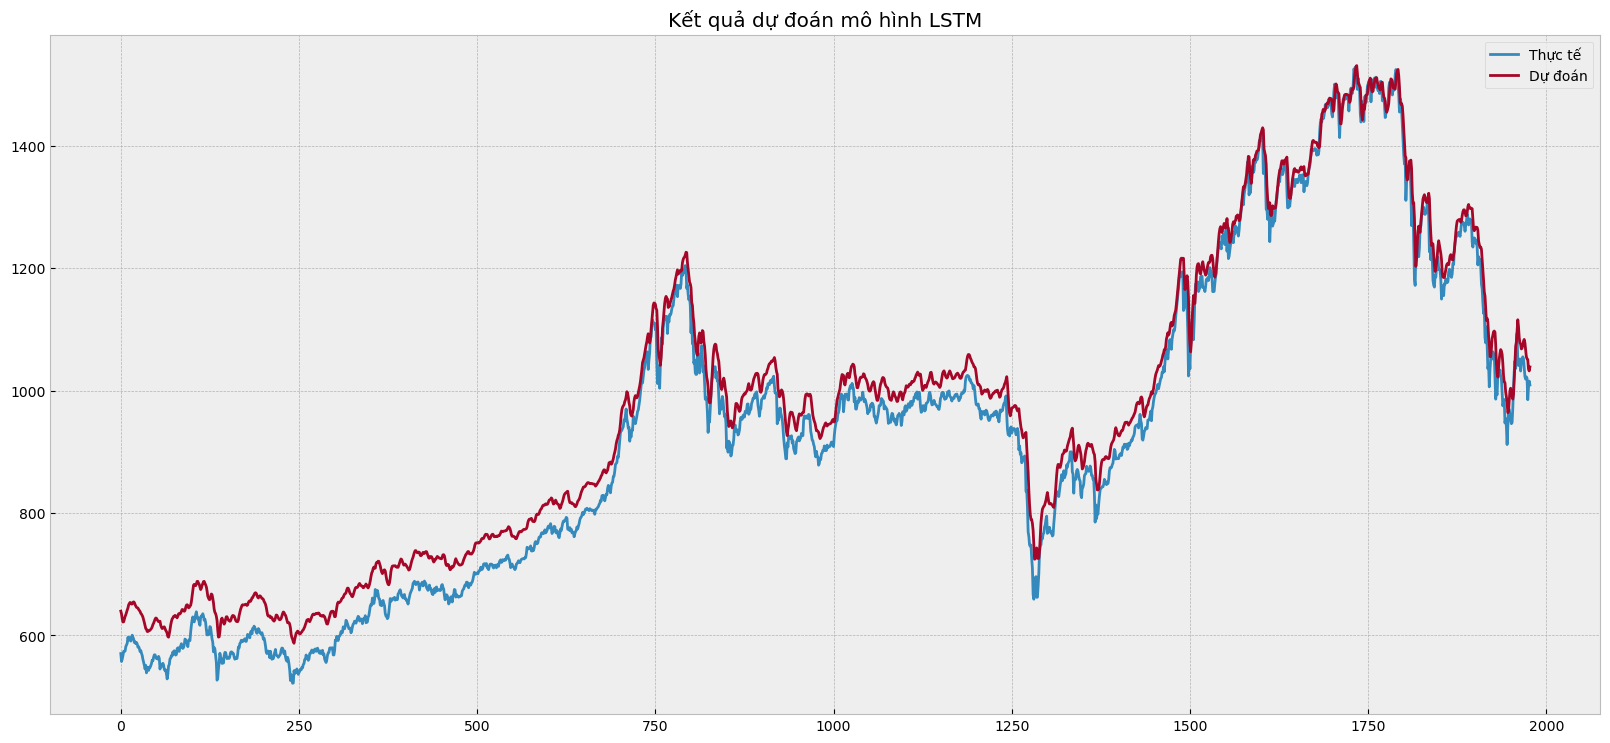

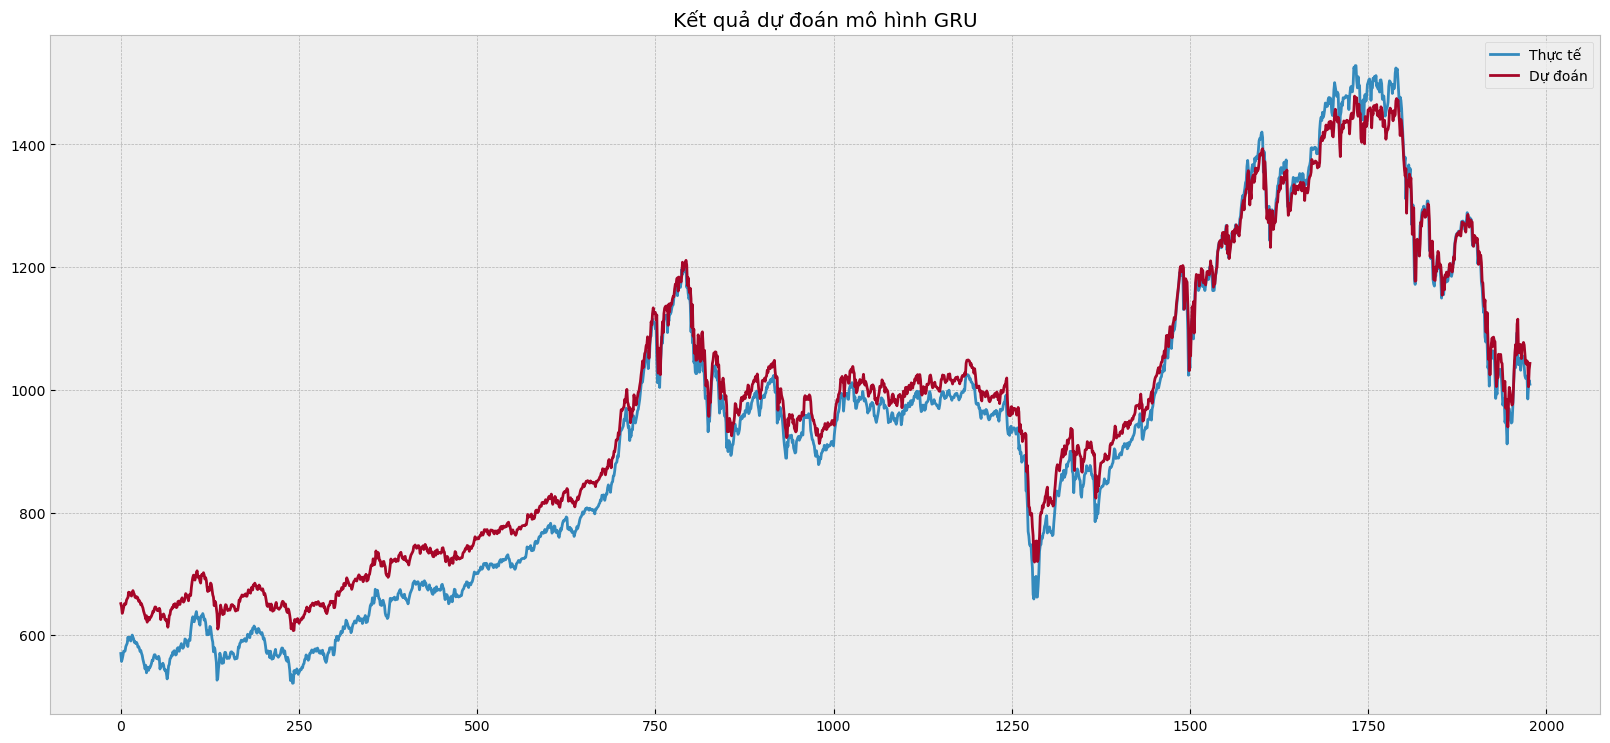

In [30]:
with plt.style.context('bmh'):
    plt.figure(figsize=[20,30])
    plt.subplot(3,1,1)
    plt.title('Kết quả dự đoán mô hình LSTM-GRU')
    plt.plot(y_train_draw,label='Thực tế')
    plt.plot(yhat_train_mix_draw,label='Dự đoán')
    plt.legend()
    plt.show()
    
    plt.figure(figsize=[20,30])
    plt.subplot(3,1,2)
    plt.plot(y_train_draw,label='Thực tế')
    plt.plot(yhat_train_LSTM_draw,label='Dự đoán')
    plt.legend()
    plt.title('Kết quả dự đoán mô hình LSTM')
    plt.show()

    plt.figure(figsize=[20,30])
    plt.subplot(3,1,3)
    plt.plot(y_train_draw,label='Thực tế')
    plt.plot(yhat_train_GRU_draw,label='Dự đoán')
    plt.title('Kết quả dự đoán mô hình GRU')
    plt.legend()
    plt.show()

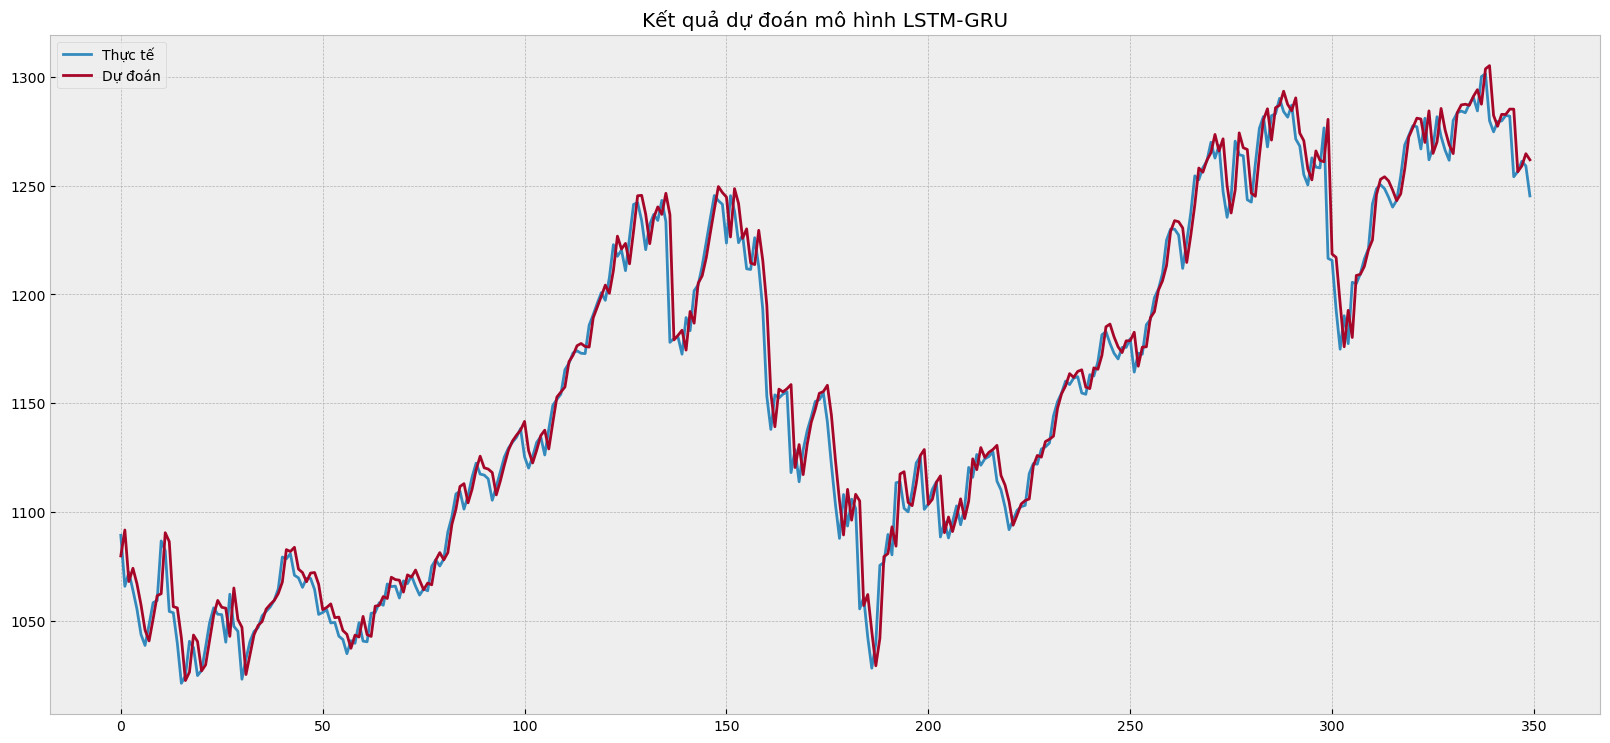

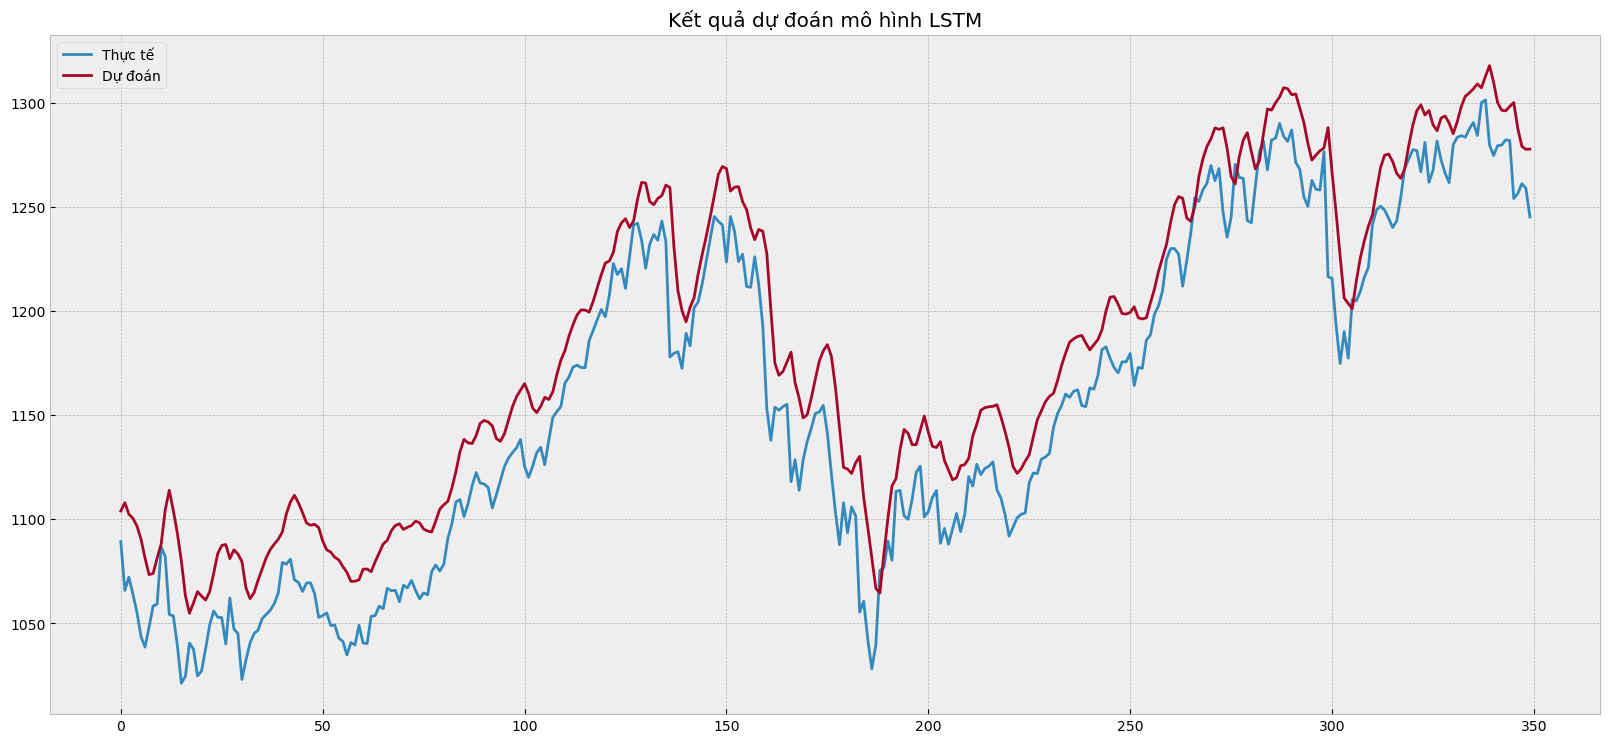

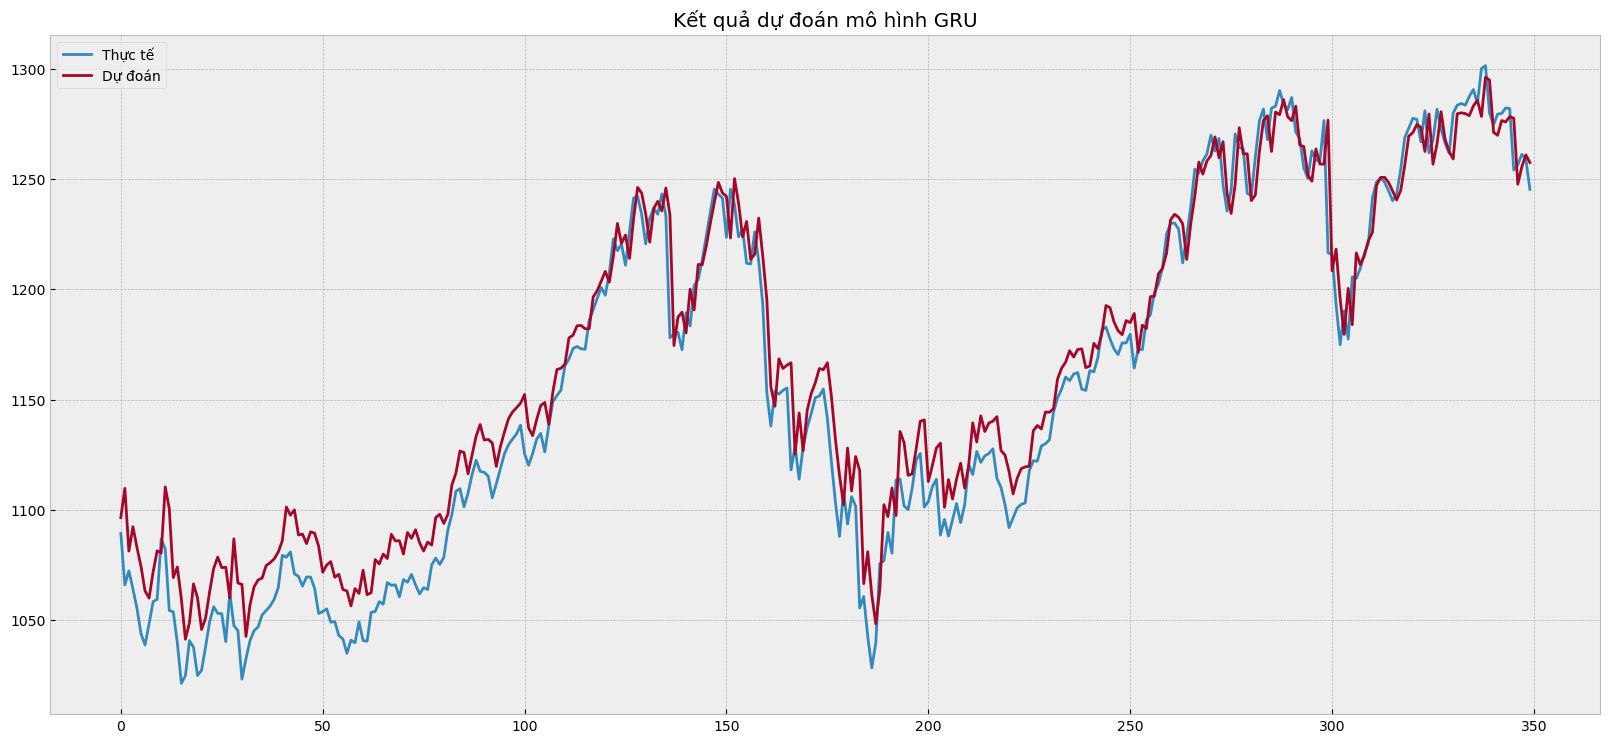

In [31]:
y_test_draw=y_test_plot.reshape(y_test_plot.shape[0],)
yhat_test_mix_draw=yhat_test_mix.reshape(yhat_test_mix.shape[0],)
yhat_test_LSTM_draw=yhat_test_LSTM.reshape(yhat_test_mix.shape[0],)
yhat_test_GRU_draw=yhat_test_GRU.reshape(yhat_test_mix.shape[0],)

with plt.style.context('bmh'):
    plt.figure(figsize=[20,30])
    plt.subplot(3,1,1)
    plt.title('Kết quả dự đoán mô hình LSTM-GRU')
    plt.plot(y_test_draw,label='Thực tế')
    plt.plot(yhat_test_mix_draw,label='Dự đoán')
    plt.legend()
    plt.show()
    
    plt.figure(figsize=[20,30])
    plt.subplot(3,1,2)
    plt.plot(y_test_draw,label='Thực tế')
    plt.plot(yhat_test_LSTM_draw,label='Dự đoán')
    plt.legend()
    plt.title('Kết quả dự đoán mô hình LSTM')
    plt.show()

    plt.figure(figsize=[20,30])
    plt.subplot(3,1,3)
    plt.plot(y_test_draw,label='Thực tế')
    plt.plot(yhat_test_GRU_draw,label='Dự đoán')
    plt.title('Kết quả dự đoán mô hình GRU')
    plt.legend()
    plt.show()